## Heat budget analysis

In [1]:
import warnings
import os
warnings.simplefilter(action='ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json'

# esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-virtual-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-cm3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json
Plot folder path:  /g/data/tm70/kr4383/access-cm3-paper-figs/


In [3]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import numpy as np
import cmocean as cm

In [4]:
# client = Client(threads_per_worker=1)
# print(client.dashboard_link)

/proxy/8787/status


In [4]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [ ]:
# %%time

# nyears = 20

# # var_names = ['opottempdiff', 'opottemppmdiff', 
# #              'rsdoabsorb', 'Th_tendency_vert_remap', 'opottemptend', 'T_advection_xy',
# #             'boundary_forcing_heat_tendency', 'frazil_heat_tendency']

# var_names = ['Th_tendency_vert_remap', 'T_advection_xy']

# heat_tendencies = dict()

# for var_name in var_names:
#     print('Loading', var_name)
#     darr = datastore.search(variable=var_name, frequency="1mon").to_dask(
#         xarray_open_kwargs = dict(
#             chunks={"yh": "auto", "xh": "auto", "time": 12},
#             decode_timedelta=True
#         )
#     )
#     heat_tendencies[var_name] = darr[var_name].isel(
#         time=slice(0, 12 * nyears)
#     ).mean(dim='time').compute()

#     heat_tendencies[var_name].to_netcdf(os.path.join(plotfolder, f"{var_name}_{nyears}_years.nc"))


Loading Th_tendency_vert_remap


In [8]:
# client.close()

In [5]:
wet = datastore.search(variable="wet")
wet.df.drop_duplicates(subset='filename', inplace=True)
wet = wet.to_dask().compute()

areacello = datastore.search(variable="areacello")
areacello.df.drop_duplicates(subset='filename', inplace=True)
areacello = areacello.to_dask().compute()

areacello = (areacello.areacello * (wet.wet == 1.0))

In [6]:
%%time

nyears = 20

var_names = [
    'opottempdiff', 'opottemppmdiff', 'opottemptend', 
    'rsdoabsorb', 'Th_tendency_vert_remap', 'T_advection_xy']
labels = [
    'Diabatic diffusion', 'Neutral diffusion', 'Total', 
    'Penetrating shortwave', 'Vertical advection + remap', 'Horizontal advection']

heat_tendencies = dict()

for var_name in var_names:
    print('Loading', var_name)
    fp = os.path.join(plotfolder, f"{var_name}_{nyears}_years.nc")
    heat_tendencies[var_name] = xr.load_dataset(fp)[var_name]

heat_tendencies = xr.Dataset(heat_tendencies)

Loading opottempdiff
Loading opottemppmdiff
Loading opottemptend
Loading rsdoabsorb
Loading Th_tendency_vert_remap
Loading T_advection_xy
CPU times: user 3.14 s, sys: 20.9 s, total: 24 s
Wall time: 31.8 s


In [7]:
print(abs(heat_tendencies['opottempdiff'].sum(dim='z_l')).max().data)
print(abs(heat_tendencies['opottemppmdiff'].sum(dim='z_l')).max().data)

0.00048828125
959.8382568359375


In [8]:
avg_heat_tendencies = dict()

for var_name in var_names:
    avg_heat_tendencies[var_name] = heat_tendencies[var_name].weighted(areacello).sum(dim=('xh', 'yh'))
    avg_heat_tendencies[var_name] /= areacello.sum()

avg_heat_tendencies = xr.Dataset(avg_heat_tendencies)

In [9]:
print(abs(avg_heat_tendencies['opottempdiff'].sum(dim='z_l')).data)
print(abs(avg_heat_tendencies['opottemppmdiff'].sum(dim='z_l')).data)

7.582043159222625e-09
3.130992939416079e-11


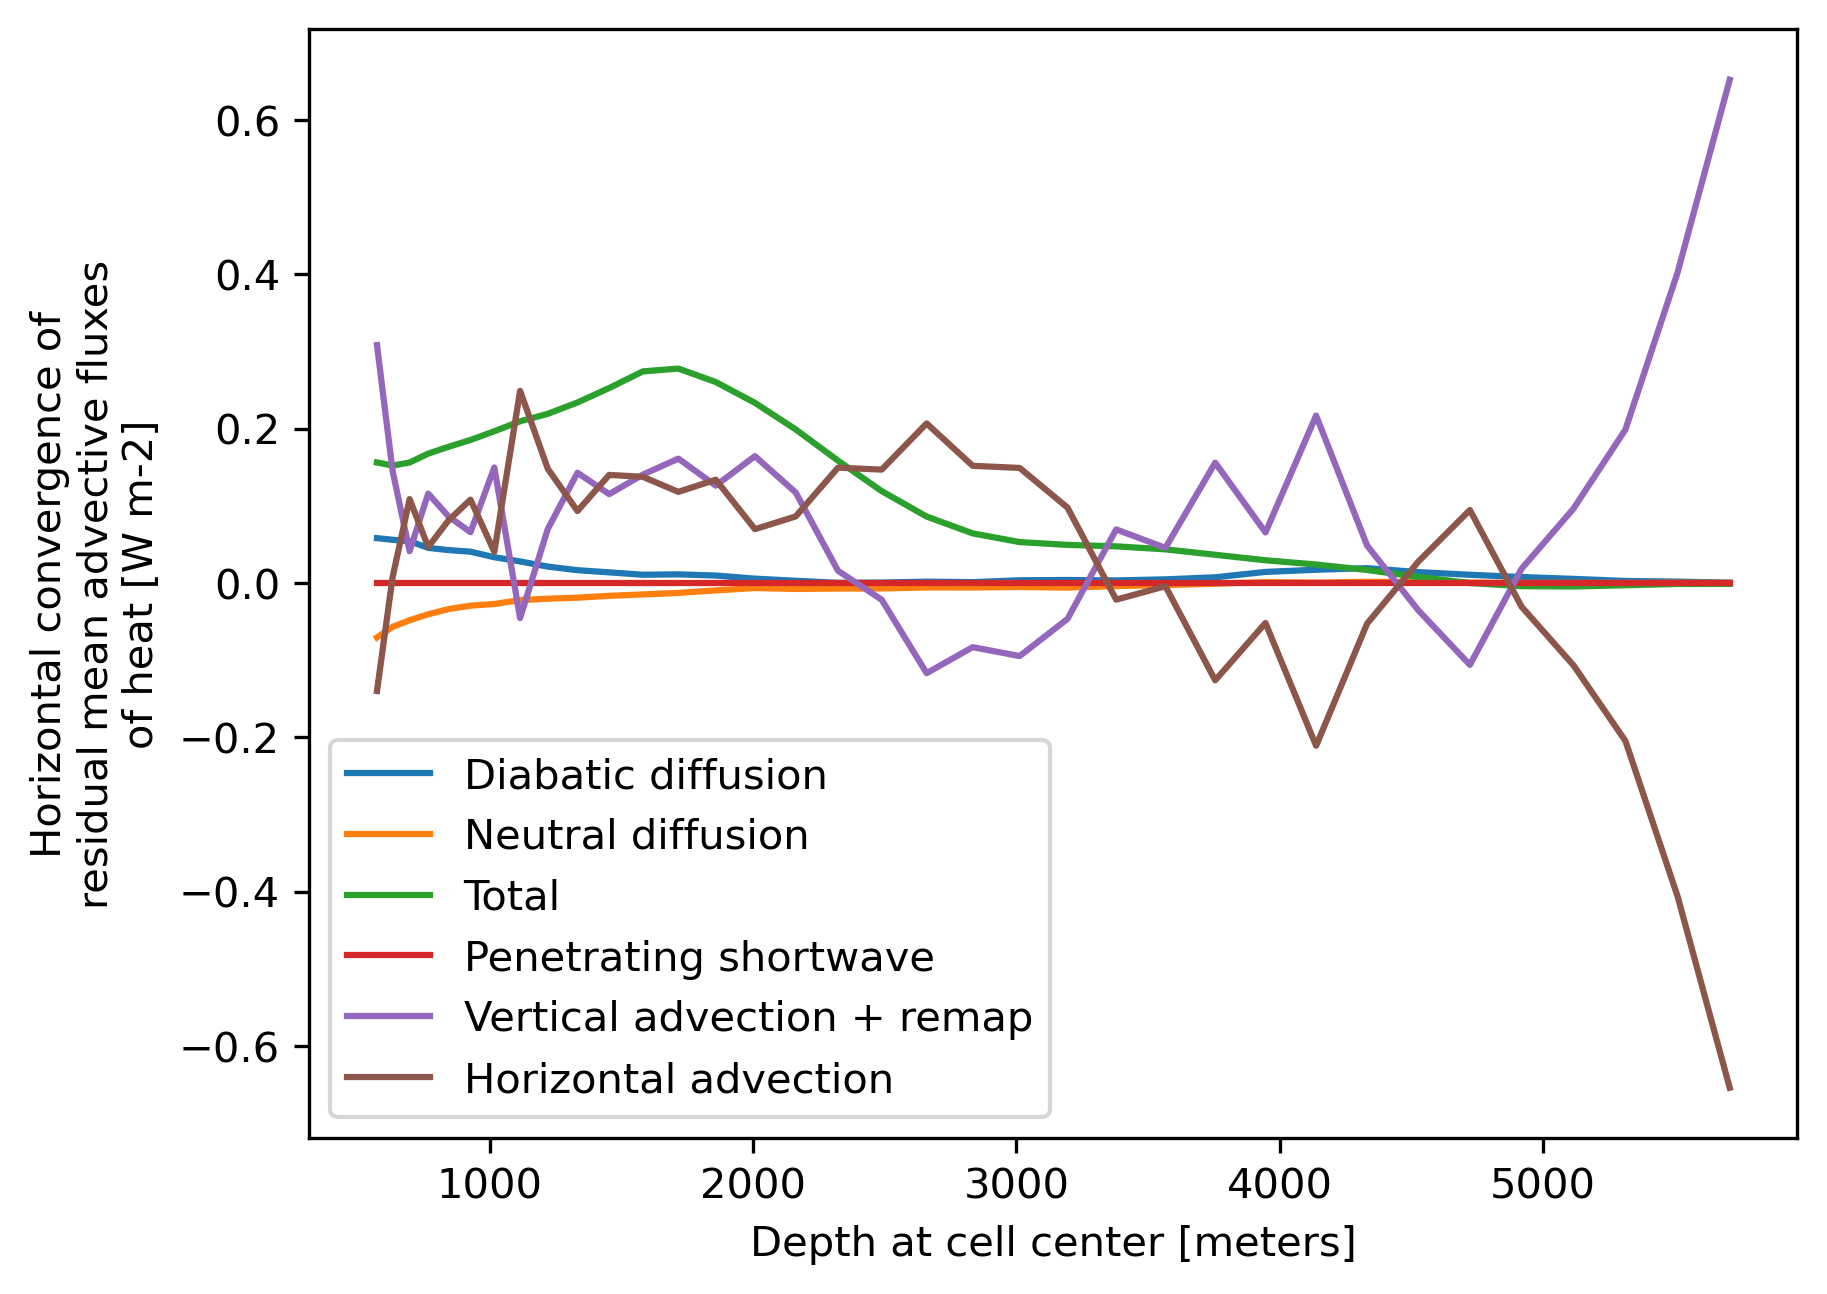

In [11]:
for var_name, label in zip(var_names, labels):
    avg_heat_tendencies[var_name].isel(z_l=slice(40, None)).plot(label=label)
    
plt.legend()

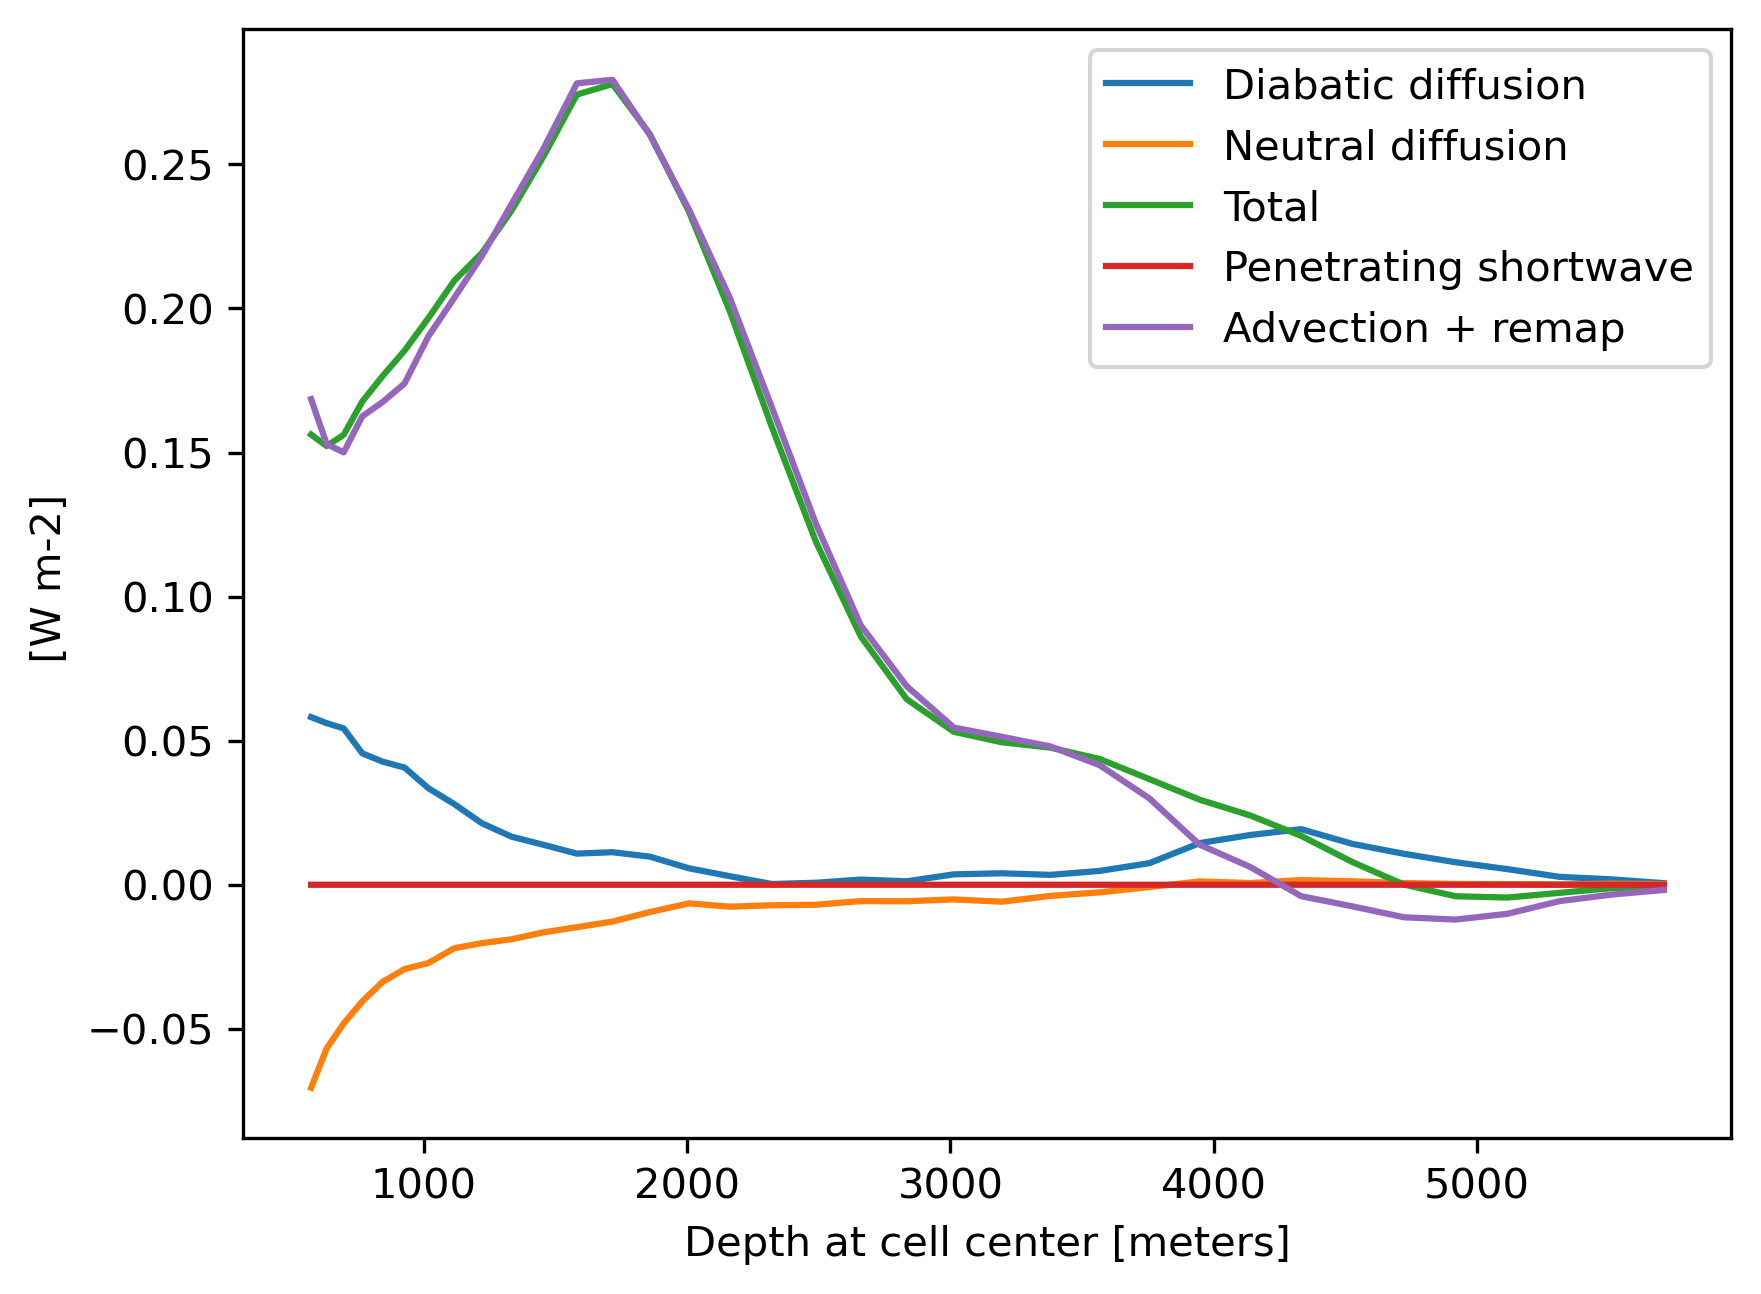

In [12]:
for var_name, label in zip(var_names[:-2], labels[:-2]):
    avg_heat_tendencies[var_name].isel(z_l=slice(40, None)).plot(label=label)

advection_heat_tendency = avg_heat_tendencies['Th_tendency_vert_remap'] + avg_heat_tendencies['T_advection_xy']
advection_heat_tendency.isel(z_l=slice(40, None)).plot(label='Advection + remap')

plt.legend()